In [ ]:
!pip install transformers datasets torch gensim tensorflow scikit-learn -q
!pip install arabic-reshaper python-bidi imbalanced-learn -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 32.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 299.6/299.6 kB 10.9 MB/s eta 0:00:00


# Word2Vec embeddings (CBOW, 300-d, window=5) were trained directly on the A-MASA corpus following the same architecture as AraVec-Twitter, since the original pre-trained file is no longer publicly accessible.

In [ ]:
from gensim.models import Word2Vec
import pandas as pd

df = pd.read_csv("combined_data.csv")
sentences = df["Sentences_clean"].dropna().astype(str).apply(str.split).tolist()

aravec_local = Word2Vec(
    sentences,
    vector_size = 300,
    window      = 5,
    min_count   = 2,
    workers     = 4,
    sg          = 0,
    epochs      = 10,
    seed        = 42,
)
wv        = aravec_local.wv
EMBED_DIM = wv.vector_size

print(f"✅ Vocab: {len(wv.key_to_index):,} | Dim: {EMBED_DIM}")

✅ Vocab: 14,502 | Dim: 300


In [ ]:
test_word = list(wv.key_to_index.keys())[0]
print(f"Test word: {test_word}")
print("Similar words:", wv.most_similar(test_word, topn=5))

Test word: من
Similar words: [('الدرويش', 0.8998762965202332), ('رهييييييييييييييييب', 0.862339973449707), ('زرتها', 0.8613611459732056), ('لمشاهدتها', 0.8611509799957275), ('واقدم', 0.8567968010902405)]


In [ ]:
import pandas as pd
import re
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
SEED     = 42
MAX_LEN  = 100
MAX_WORDS = 30_000

df = pd.read_csv("combined_data.csv")
df = df.dropna(subset=["Sentences_clean","unified_sentiment"]).copy()
df["unified_sentiment"] = pd.to_numeric(df["unified_sentiment"], errors="coerce")
df = df.dropna(subset=["unified_sentiment"])
label_map = {-1.0: 0, 0.0: 1, 1.0: 2}
df["label"] = df["unified_sentiment"].map(label_map)
X = df["Sentences_clean"].astype(str).tolist()
y = df["label"].astype(int).tolist()
domains = df["domain_name"].tolist()

X_train, X_temp, y_train, y_temp, dom_train, dom_temp = train_test_split(
    X, y, domains, test_size=0.2, random_state=SEED, stratify=y)
X_val, X_test, y_val, y_test, dom_val, dom_test = train_test_split(
    X_temp, y_temp, dom_temp, test_size=0.5, random_state=SEED, stratify=y_temp)

tokenizer_keras = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
tokenizer_keras.fit_on_texts(X_train)

X_train_seq = pad_sequences(tokenizer_keras.texts_to_sequences(X_train),
                             maxlen=MAX_LEN, padding="post", truncating="post")
X_val_seq   = pad_sequences(tokenizer_keras.texts_to_sequences(X_val),
                             maxlen=MAX_LEN, padding="post", truncating="post")
X_test_seq  = pad_sequences(tokenizer_keras.texts_to_sequences(X_test),
                             maxlen=MAX_LEN, padding="post", truncating="post")
import numpy as np
from tensorflow.keras.utils import to_categorical
y_train_cat = to_categorical(y_train, 3)
y_val_cat   = to_categorical(y_val,   3)
y_test_cat  = to_categorical(y_test,  3)

print(f"Train: {X_train_seq.shape} | Val: {X_val_seq.shape} | Test: {X_test_seq.shape}")

Train: (4848, 100) | Val: (606, 100) | Test: (606, 100)


In [ ]:
word_index = tokenizer_keras.word_index
vocab_size  = min(MAX_WORDS, len(word_index)) + 1

embed_matrix = np.zeros((vocab_size, EMBED_DIM), dtype="float32")
found = 0
for word, i in word_index.items():
    if i >= vocab_size:
        continue
    if word in wv:
        embed_matrix[i] = wv[word]
        found += 1

coverage = found / vocab_size * 100
print(f"Embedding coverage: {found}/{vocab_size} ({coverage:.1f}%)")

Embedding coverage: 13976/30001 (46.6%)


In [ ]:
import tensorflow as tf
from tensorflow.keras import Sequential, layers, regularizers, callbacks

tf.random.set_seed(SEED)

model_bilstm = Sequential([
    layers.Embedding(vocab_size, EMBED_DIM,
                     weights=[embed_matrix],
                     input_length=MAX_LEN,
                     trainable=False),
    layers.SpatialDropout1D(0.3),
    layers.Bidirectional(layers.LSTM(128, return_sequences=True,
                                     dropout=0.3, recurrent_dropout=0.2)),
    layers.Bidirectional(layers.LSTM(64,
                                     dropout=0.3, recurrent_dropout=0.2)),
    layers.Dense(64, activation="relu",
                 kernel_regularizer=regularizers.l2(1e-4)),
    layers.Dropout(0.4),
    layers.Dense(3, activation="softmax"),
])

model_bilstm.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=2e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)
model_bilstm.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │     9,000,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,000,300 (34.33 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 9,000,300 (34.33 MB)

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights_arr = compute_class_weight(
    "balanced", classes=np.array([0,1,2]), y=np.array(y_train))
class_weights = dict(enumerate(class_weights_arr))
print("Class weights:", class_weights)

cb_list = [
    callbacks.ModelCheckpoint(
        "bilstm_best.h5",
        monitor         = "val_accuracy",
        save_best_only  = True,
        mode            = "max",
        verbose         = 1,
    ),
    callbacks.EarlyStopping(
        monitor              = "val_accuracy",
        patience             = 4,
        restore_best_weights = True,
        mode                 = "max",
        verbose              = 1,
    ),
    callbacks.ReduceLROnPlateau(
        monitor   = "val_accuracy",
        factor    = 0.5,
        patience  = 2,
        min_lr    = 1e-5,
        mode      = "max",
        verbose   = 1,
    ),
]

history = model_bilstm.fit(
    X_train_seq, y_train_cat,
    validation_data = (X_val_seq, y_val_cat),
    epochs          = 20,
    batch_size      = 64,
    class_weight    = class_weights,
    callbacks       = cb_list,
    verbose         = 1,
)

Class weights: {0: np.float64(2.825174825174825), 1: np.float64(4.987654320987654), 2: np.float64(0.4089068825910931)}
Epoch 1/20
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4517 - loss: 1.0743
Epoch 1: val_accuracy improved from None to 0.59736, saving model to bilstm_best.h5



Epoch 1: finished saving model to bilstm_best.h5
76/76 ━━━━━━━━━━━━━━━━━━━━ 117s 1s/step - accuracy: 0.4319 - loss: 1.0873 - val_accuracy: 0.5974 - val_loss: 0.9862 - learning_rate: 0.0020
Epoch 2/20
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5936 - loss: 1.0127
Epoch 2: val_accuracy did not improve from 0.59736
76/76 ━━━━━━━━━━━━━━━━━━━━ 102s 1s/step - accuracy: 0.5716 - loss: 1.0355 - val_accuracy: 0.5644 - val_loss: 1.0300 - learning_rate: 0.0020
Epoch 3/20
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5731 - loss: 0.9953
Epoch 3: val_accuracy did not improve from 0.59736

Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0010000000474974513.
76/76 ━━━━━━━━━━━━━━━━━━━━ 141s 1s/step - accuracy: 0.5590 - loss: 1.0208 - val_accuracy: 0.5462 - val_loss: 1.0170 - learning_rate: 0.0020
Epoch 4/20
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5851 - loss: 0.9687
Epoch 4: val_accuracy did not improve from 0.59736
76/76 ━━━━━━━━━━━━━━━━━━━━ 101s 1s/step - accuracy:


Epoch 5: finished saving model to bilstm_best.h5
76/76 ━━━━━━━━━━━━━━━━━━━━ 100s 1s/step - accuracy: 0.5879 - loss: 0.9870 - val_accuracy: 0.6931 - val_loss: 0.8120 - learning_rate: 0.0010
Epoch 6/20
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6269 - loss: 0.9416
Epoch 6: val_accuracy did not improve from 0.69307
76/76 ━━━━━━━━━━━━━━━━━━━━ 103s 1s/step - accuracy: 0.6002 - loss: 0.9648 - val_accuracy: 0.5512 - val_loss: 0.9723 - learning_rate: 0.0010
Epoch 7/20
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5855 - loss: 0.9459
Epoch 7: val_accuracy did not improve from 0.69307

Epoch 7: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
76/76 ━━━━━━━━━━━━━━━━━━━━ 102s 1s/step - accuracy: 0.5916 - loss: 0.9663 - val_accuracy: 0.6304 - val_loss: 0.8594 - learning_rate: 0.0010
Epoch 8/20
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6090 - loss: 0.9147
Epoch 8: val_accuracy did not improve from 0.69307
76/76 ━━━━━━━━━━━━━━━━━━━━ 140s 1s/step - accuracy:

✅ Loaded best val_accuracy checkpoint
19/19 ━━━━━━━━━━━━━━━━━━━━ 8s 324ms/step
     BiLSTM+AraVec — Test Set Report
              precision    recall  f1-score   support

    Negative       0.35      0.82      0.49        72
     Neutral       0.19      0.25      0.21        40
    Positive       0.95      0.73      0.83       494

    accuracy                           0.71       606
   macro avg       0.49      0.60      0.51       606
weighted avg       0.82      0.71      0.75       606



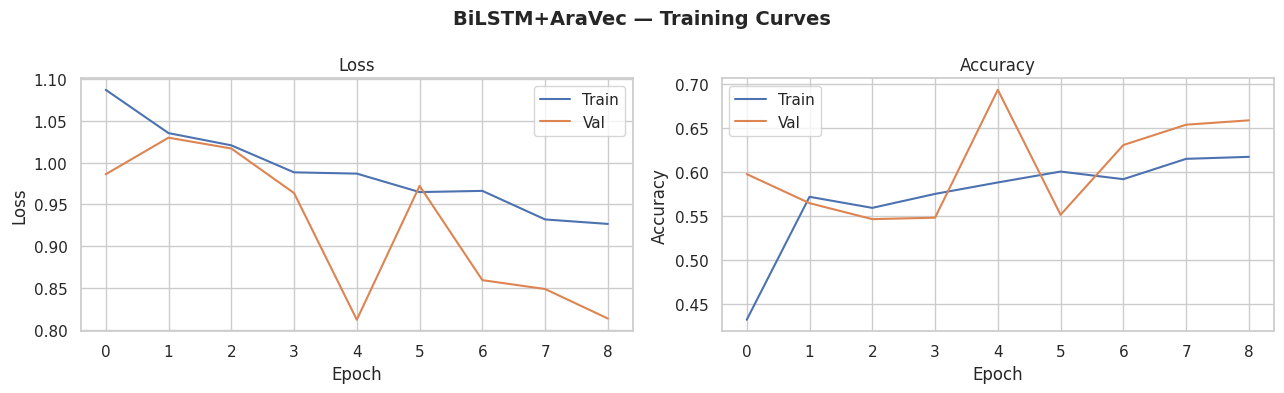

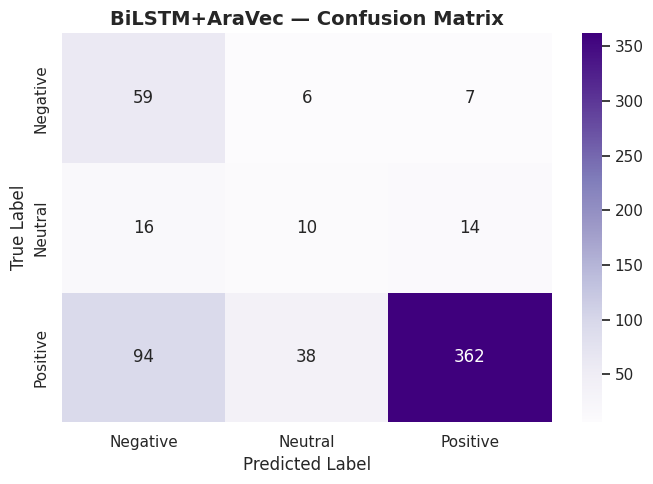

/tmp/ipykernel_2032/250911211.py:46: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: f1_score(g["true"], g["pred"], average="macro"))
/tmp/ipykernel_2032/250911211.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars    = sns.barplot(data=domain_f1, x="domain", y="F1_Macro", palette=palette)


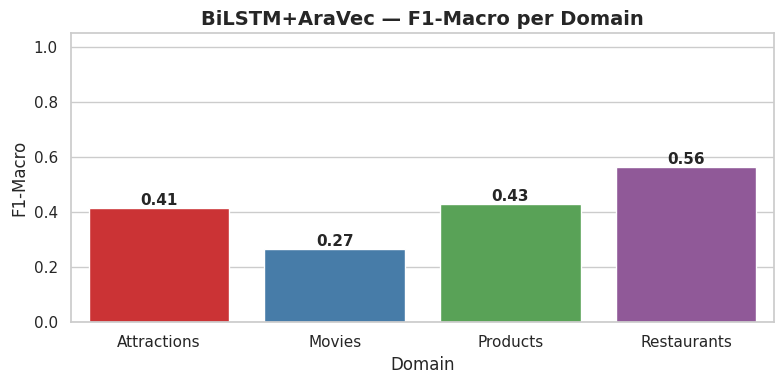

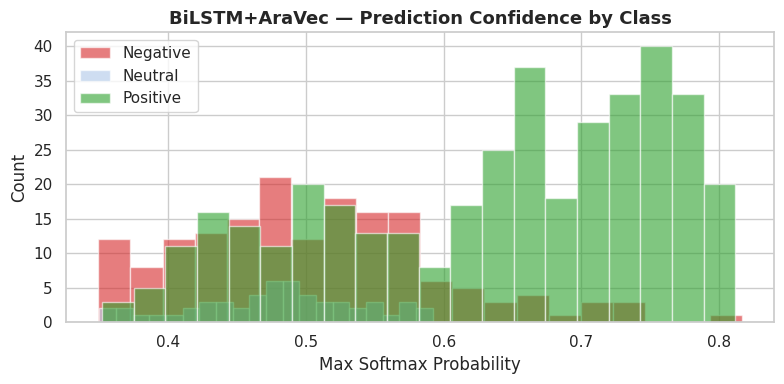

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import (classification_report, confusion_matrix, f1_score)
model_bilstm.load_weights("bilstm_best.h5")
print("✅ Loaded best val_accuracy checkpoint")

sns.set_theme(style="whitegrid")
label_names = ["Negative", "Neutral", "Positive"]

y_pred_prob = model_bilstm.predict(X_test_seq)
y_pred      = np.argmax(y_pred_prob, axis=-1)

print("=" * 55)
print("     BiLSTM+AraVec — Test Set Report")
print("=" * 55)
print(classification_report(y_test, y_pred, target_names=label_names))
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(history.history["loss"],     label="Train")
axes[0].plot(history.history["val_loss"], label="Val")
axes[0].set(title="Loss", xlabel="Epoch", ylabel="Loss")
axes[0].legend()

axes[1].plot(history.history["accuracy"],     label="Train")
axes[1].plot(history.history["val_accuracy"], label="Val")
axes[1].set(title="Accuracy", xlabel="Epoch", ylabel="Accuracy")
axes[1].legend()

plt.suptitle("BiLSTM+AraVec — Training Curves", fontsize=14, fontweight="bold")
plt.tight_layout(); plt.show()
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Purples",
            xticklabels=label_names, yticklabels=label_names)
plt.title("BiLSTM+AraVec — Confusion Matrix", fontsize=14, fontweight="bold")
plt.ylabel("True Label"); plt.xlabel("Predicted Label")
plt.tight_layout(); plt.show()

test_df    = pd.DataFrame({"domain": dom_test, "true": y_test, "pred": y_pred})
domain_f1  = (test_df.groupby("domain")
              .apply(lambda g: f1_score(g["true"], g["pred"], average="macro"))
              .reset_index(name="F1_Macro"))

plt.figure(figsize=(8, 4))
palette = sns.color_palette("Set1", len(domain_f1))
bars    = sns.barplot(data=domain_f1, x="domain", y="F1_Macro", palette=palette)
for bar, val in zip(bars.patches, domain_f1["F1_Macro"]):
    bars.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
              f"{val:.2f}", ha="center", fontsize=11, fontweight="bold")
plt.title("BiLSTM+AraVec — F1-Macro per Domain", fontsize=14, fontweight="bold")
plt.ylim(0, 1.05); plt.xlabel("Domain"); plt.ylabel("F1-Macro")
plt.tight_layout(); plt.show()

confidence = y_pred_prob.max(axis=1)
plt.figure(figsize=(8, 4))
for cls, col in zip([0,1,2], ["#d62728","#aec7e8","#2ca02c"]):
    mask = y_pred == cls
    plt.hist(confidence[mask], bins=20, alpha=0.6,
             label=label_names[cls], color=col)
plt.title("BiLSTM+AraVec — Prediction Confidence by Class",
          fontsize=13, fontweight="bold")
plt.xlabel("Max Softmax Probability"); plt.ylabel("Count")
plt.legend(); plt.tight_layout(); plt.show()